# Deliverable 3
* See the [GSoC fork of `ioos_qc`](https://github.com/Klankers/ioos_qc/) for the code implemented following the research and development in this notebook.
* See the [IOOS GSoC project proposal](https://github.com/ioos/gsoc/issues/102) for more details on origin.

**Soft end date of October 22**
*Complete assessment of a subset of tests.*

| Stage | Stage specifications | Time required | Start-End |
| ----- | -------------------- | ------------- | --------- |
| 1 | Learn about the community and note shortcomings or additional toolboxes, such that the wheel need not be reinvented. | 3 weeks | May 1 - May 24 |
| 2 | Begin test assessments and complete Group 1 “required” tests. | 14 weeks | May 25 - Sept 3 |
| 3 | Assess immediately applicable "follow up" tests. | 7 weeks | Sept 4 - Oct 22 |
| 4 | Finalize documentation. | 2 weeks | Oct 23 - Nov 2 |

Final submission of the extended project due the week of November 2nd. Note that this should include a Jupyter notebook submission to the [IOOS code lab](https://ioos.github.io/ioos_code_lab/content/intro.html).

Following a recent meeting with my mentors, we agreed that a huge amount of learning, networking, and coding has been done on the toolbox, though it has come with a cost of increased time spent on the "required" tests. While it is encouraging to see the updates from this project and the value gained from networking directly with the toolbox's users, we need to constrain the remainder of the tests to whatever is manageable.

As such, we're constraining the number of tests based on priority:
* **Density inversion test** ("suggested" test) - high similarity to the previous "pressure" test, making for a good segue following a recent hack week where I didn't manage to work on the toolbox at all.
* **Climatology test** ("strongly recommended") - potentially the most complicated test, structured unlike the others within `qartod.py`. It has a large user base, though potentially few of them are using it as intended. Improving the codebase for it is therefore a priority to 1) guarantee it isn't a barrier for future users and 2) ensure that it is working as intended.

*Any tests below would be considered a bonus*
* **Spike test** ("strongly recommended") - recent interactions with QARTOD users have described it as ineffective.
* Checking toolbox contents: It was a surprise when the timing and syntax tests were missing. Are the remaining tests in the manual present in the codebase (`qartod.py` or `argo.py`)? Prioritize those that are not.
    * Absent from the code (prioritizing):
        * **Multi-Variate** ("suggested")
        * **Previous profile** ("suggested")
        * **TS curve/space test** ("suggested")
    * Present in the code (deprioritizing):
        * **Rate of change** ("strongly recommended")
        * **Flat line** ("strongly recommended")
        * **Attenuated signal** ("suggested")

I'll quickly add that, though it isn't our manual, the [IOOS underwater optics manual](https://cdn.ioos.noaa.gov/media/2017/12/QARTODOceanOptics_v1.1_Final.pdf) says:
> However, for some critical, real-time applications with high risk operations, it may be advisable to invoke all groups [of tests].

So at some point, someone's *wanted* to run the previous profile and TS curve tests along with everything else for high risk operations. I think that's a strong argument that, even though I've prioritized by the glider manual's hierarchy, **all** of the tests carry value and deserve to be looked at.

## Imports
Begin the deliverables notebook with essential imports. In theory, this should be all you need to run the tests.
* typing
* data wrangling and visualization
* dataset imports
* the QARTOD flags

I might include this Python cell with the `code` or `actions` sections of each test below, such that I don't need to rerun the whole notebook. By the end of deliverable 2, the notebook took several minutes to run and may have gotten a little bloated.

In [1]:
from collections.abc import Sequence
from numbers import Real
import warnings
import numpy as np
import xarray as xr
fpath = "/home/aaron-mau/Data/OG1/delayed_SEA056_M102.nc"
ds = xr.load_dataset(fpath)
class QartodFlags:
    """Primary flags for QARTOD."""
    GOOD = 1
    UNKNOWN = 2
    SUSPECT = 3
    FAIL = 4
    MISSING = 9
FLAGS = QartodFlags  # Default name for all check modules
NOTEVAL_VALUE = QartodFlags.UNKNOWN

In [2]:
import matplotlib.pyplot as plt

## Density Inversion Test
* How is it described in the manual
* How is it represented in the code
* Does anything need to be done in either?

### Manual description
As mentioned before, this segues well after working on the `pressure increasing` test for `argo.py` and `pressure test` for `qartod.py` prior to OHW'26.

This is described as a **suggested** test, so by itself it isn't the highest priority. This is the first test of this class to be worked on and the heirarchy of tests would best summarize them as "optional". There isn't a genuine "description" of these tests outside of their classification, so it isn't quite clear what the user gains from each. From my summarization of the manual thus far, I'd describe them as follows:
* Required: These are, well, required. If you don't do them you could expect major problems. Big data gaps. Broken data strings or positional data. Core sensors being broken and carrying over to the rest of the sensor package.
* Strongly recommended: These are some of the essential tests that, while not required, provide solid insight. Despiking, checking for flat lines, etc. are all high value tests for just about any glider sensor.
* Suggested: These are nice to pair on the side of any of the other tests. These pull more from oceanographic context and scientific insight than strict signals or statistics.

This test is essentially pairing density to pressure and confirming that they are both increasing together. This form of density is referred to as *potential* density or $\sigma_\Theta$, which if I remember correctly, requires a derived conservative temperature and absolute salinity. Yep, looks like that's what [GSW lists in the `density` module](https://teos-10.github.io/GSW-Python/density.html) (see `gsw.density.sigma0). I'm *assuming* this is referenced to 0 dbar - but the last sentance suggests that operators should be able to choose other $\sigma_t$.

Anyway, the test then says:

> When vertical profile data are obtained, this test is used to flag failed T, C, and S observations, which yield densities that do not sufficiently increase with pressure.

Which suggests that it should be returning a series of flags for those parameters. It isn't quite clear if this flag is demarcating "this *index* is bad" or "*temperature* is bad at index". The wording suggests that it *could* require looking into which factor is contributing to a bad density reading. I should add that I think we're assuming pressure is good, since it isn't mentioned in the sentance above. It's most likely that this test is intended to flag an index of the dataset, not individual components.

There is supposed to be an operator-selected density threshold that allows for some density exceptions, which is denoted as `DT` for sequential sample increments, n-1 to n. So the first point won't be flagged by this, but the last one will. Similar to the `pressure test`, this needs to work on downglides/downcasts and upglides/upcasts, so we may need a keyword argument to distinguish the sign of the cast. It says "...results produced in real time" and I'm not sure what that means, since I don't stream data or have experience with the live feed functionality of `IOOS_QC`.

The manual then says:

> From a computational point of view, this test is similar to the rate of change test (test 8). The same code can be used for both, using different variables and thresholds. As with the rate of change test, it is not known which side of the step is good versus bad.

By saying "The same code can be used for both", I'm suddenly questioning my work on the entire toolbox. Should we have been reusing the "gross_range_test" on a d/dt of the `TIME` coordinate? I think this is just another example of the manual not being correctly descriptive, as the `rate of change test` is written to describe a time series, which is not the same as $\delta \sigma_\Theta \over \delta p$. The sentance thereafter is also perhaps in error - as the previous paragraph clearly defines an index $n$ which is being examined. I would assume that, based on the previous flag ($flag_{n-1}$) you should know if the previous point was good or bad.

The manual references TEOS-10 for the defitinion of $\sigma_\Theta$, so we'll keep an eye out for `gsw` in the codebase.

This test, like many others, doesn't list a flag 9 (MISSING) but we'll want to include it with the PASS and FAIL flags. The test is described as a fail on a point $n$ if it smaller than the previous point plus the density threshold. It's weird that there is no codable condition for "SUSPECT" and it isn't described in the manual - I could envision it being like the `range test` where there is a SUSPECT bound and a FAIL bound.

> $\sigma_{\theta n-1} + DT > \sigma_{\theta n}$ flags as 4

Otherwise flag as 1. Note that the equal sign is considered 1 or PASS.

The manual wraps up with an example where DT = 0.03 kg/m^3. This aligns with what `gsw` would likely output for a value of $\sigma_\theta$.

### Code
As mentioned before, this code already exists in the toolbox.

Interestingly, this takes in the potential water density as `inp` and the pressure *or* depth values as `zinp`. The manual explicitly mentions pressure, not depth, which is similar but not identical. This test is therefore assuming that I'm doing these derivations myself prior to using it. I think this makes sense, but it might be worth clarifying suggested ways to get these params or standardizing what gets passed in. `inp` is *only* the potential density data, so as I assumed in the manual portion, we're just going to be looking at the index that is failing and not decomposing back into the source C, T, and S values to assign flags on who we think is wrong. It says that the operator should flag both temperature and salinity on the result of this test...? Is that in the TS manual that was referenced in the docstring?

This test *does* inlcude suspect and fail thresholds, rather than just one value of DT. These thresholds are most clearly described in the second line of each of the parameters in the docstring - it's the *variation* to be tolerated.

It says that it works on downcasts, upcasts, and down/up in real time but it doesn't need to be clarified in a keyword argument the way I needed to do the `pressure test`. I think this is all coming into effect in the `delta` line, where it combines with the orientation of `zinp`. However, we needed the sequence of values for the helper function in the `pressure test` to track the most extreme values. Here, we're just doing the diff twice. So it could probably get by without it for this application.

```python
delta = np.sign(np.diff(zinp)) * np.diff(inp)
```

It confirms that the arrays are the same sizes and builds a flag masked array the same way as we normally would, it's just missing the NaN mask. So we'll want to get that added.

Then it checks the input sizes to make sure that it can run something - if there's no data or only one point, it can't really do anything. So it returns a blank array or an UNKNOWN flag. Makes sense.

Finally, the thresholds we care so much about. It starts with the suspect threshold and then moves on to the fail threshold with essentially the same logic. Flagging in this order guarantees that FAIL will overwrite SUSPECT, which is what we want.

Then it... oh. Ok, so it does do a NaN mask at the end. Does that make a difference? I wonder if we could remove the `with np.errstate(invalid="ignore"):` line by simply moving it forward and doing the `valid` index checks the way we did for tests in deliverable 2.

#### Unit tests
I ran a codecov pytest on `test_qartod.py` and it seems like the following lines need coverage.

```bash
ioos_qc/qartod.py                            507     47    91%   20-21, 62-63, 84-85, 186-188, 258-260, 592, 601-618, 629-630, 636-637, 642-643, 648-649, 656-658, 745-748, 1164-1165, 1185, 1373-1374, 1381, 1456-1457, 1562
```

Given the test is presently from 1331-1408:
* 1373-1374, test this:
```python
if inp.shape != zinp.shape:
    msg = f"Density ({inp.shape}) and depth ({zinp.shape}) must be the same shape"
    raise ValueError(msg)
```

* 1381, test this:
```python
if inp.size == 0:
    return np.ma.masked_array([])
```

Very minor adjustments needed to the unit tests here. Should be pretty quick and easy to resolve once the other modifications are done.

In [3]:
def existing_density_inversion_test(
    inp: Sequence[Real],
    zinp: Sequence[Real],
    suspect_threshold: float | None = None,
    fail_threshold: float | None = None,
) -> np.ma.core.MaskedArray:
    """With few exceptions, potential water density will increase with increasing pressure. When
    vertical profile data is obtained, this test is used to flag as failed T, C, and SP observations, which
    yield densities that do not sufficiently increase with pressure. A small operator-selected density
    threshold (DT) allows for micro-turbulent exceptions. This test can be run on downcasts, upcasts,
    or down/up cast results produced in real time.

    Both Temperature and Salinity should be flagged based on the result of this test.

    Ref: Manual for Real-Time Quality Control of in-situ Temperature and Salinity Data, Version 2.0, January 2016

    Parameters
    ----------
    inp
        Potential density values as a numeric numpy array or a list of numbers.
    zinp
        Corresponding depth/pressure values for each density.
    suspect_threshold
        A float value representing a maximum potential density(or sigma0)
        variation to be tolerated, downward density variation exceeding this will be flagged as SUSPECT.
    fail_threshold
        A float value representing a maximum potential density(or sigma0)
        variation to be tolerated, downward density variation exceeding this will be flagged as FAIL.

    Returns
    -------
    flag_arr
        A masked array of flag values equal in size to that of the input.

    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        inp = np.ma.masked_invalid(np.array(inp).astype(np.float64))
        zinp = np.ma.masked_invalid(np.array(zinp).astype(np.float64))

    # Make sure both inputs are the same size.
    if inp.shape != zinp.shape:
        msg = f"Density ({inp.shape}) and depth ({zinp.shape}) must be the same shape"
        raise ValueError(msg)

    # Start with everything as passing
    flag_arr = QartodFlags.GOOD * np.ma.ones(inp.size, dtype="uint8")

    # If no data or just one record, return respectively an empty mask array or UNKNOWN
    if inp.size == 0:
        return np.ma.masked_array([])
    inp_size = 2
    if inp.size < inp_size:
        flag_arr[0] = QartodFlags.UNKNOWN
        return flag_arr

    # Compute the vertical density variability along zinp and flip delta according to zinp variation direction
    delta = np.sign(np.diff(zinp)) * np.diff(inp)

    if suspect_threshold is not None:
        with np.errstate(invalid="ignore"):
            is_suspect = delta < suspect_threshold
            if any(is_suspect):
                flag_arr[:-1][is_suspect == True] = QartodFlags.SUSPECT  # noqa:E712 - Previous value
                flag_arr[1:][is_suspect == True] = QartodFlags.SUSPECT  # noqa:E712 - Reversed value

    if fail_threshold is not None:
        with np.errstate(invalid="ignore"):
            is_fail = delta < fail_threshold
            if any(is_fail):
                flag_arr[:-1][is_fail == True] = QartodFlags.FAIL  # noqa:E712 - Previous value
                flag_arr[1:][is_fail == True] = QartodFlags.FAIL  # noqa:E712 - Reversed Value

    # If the value or depth is masked set the flag to MISSING for this record and the following one.
    is_missing = inp.mask | zinp.mask
    flag_arr[is_missing] = QartodFlags.MISSING
    flag_arr[1:][is_missing[:-1]] = QartodFlags.MISSING
    return flag_arr

### Actions
1. Check out the BP that was mentioned in the docstring. I think [this is the most recent one](https://cdn.ioos.noaa.gov/media/2020/03/QARTOD_TS_Manual_Update2_200324_final.pdf)? This differs from the glider manual - there are a different number of tests and the test description here is slightly different.
2. Test it out on some real data. Make sure that it works on the downcast, upcast, and whatever the down/up together means.
3. Try creating the `valid` indexes and creating a NaN mask the way we did before. 

#### Reviewing this other BP
Ok, so regarding the other BP, it isn't actually too different. At least where the test is brought up.

For reference, here are the two texts:
1. [The 2016 Glider BP manual](https://cdn.ioos.noaa.gov/media/2017/12/Manual-for-QC-of-Glider-Data_05_09_16.pdf)
2. [The 2020 TS manual](https://cdn.ioos.noaa.gov/media/2020/03/QARTOD_TS_Manual_Update2_200324_final.pdf)

* S is referred to as SP in the 2020 TS manual, which is a better description.
* Upglides and downglides are referred to as upcasts and downcasts in the 2020 TS manual, which is also a better, more generic description.
* The 2020 TS manual describes that the *time* axis would need to be replaced by *depth* if using the rate of change test for this code.
* The 2020 TS manual drops the "operators may choose a different measure of density" line, which is also nice. It removes ambiguity.

Interestingly, the 2020 TS manual actually describes the `climatological test` as a required test, and completely drops the `pressure test` that is present in the 2016 glider manual. This is probably another reason to bump the climatology test up in priority - but I'm glad that I took this route with the `density inversion test` first, because otherwise I might not have discovered this!

Speaking with my mentor yesterday, it became clear that the IOOS QARTOD toolbox has had a lot of different applications and authors from a scientific background, which is part of why there are so [many different IOOS manuals](https://ioos.noaa.gov/project/qartod/). Lots of different subgroups building different things and the synthesis isn't quite there yet.

If Filipe hasn't already, some of these manuals ([example](https://cdn.ioos.noaa.gov/media/2017/12/QARTODOceanOptics_v1.1_Final.pdf)) request that manual users notify the "qartod board" at NOAA. I think this is the committee he's talked about. It might be worth emailing them at the end of the project and thinking about doing a version update to the glider manual, which is now 10 years old.
* The example manual I referred to includes *several* other tests that aren't in this toolbox. Might be a good project for future GSoC contributors!
    * Decreasing Radiance, Irradiance, and PAR tests
    * Photic Zone Limit test.
* [Another manual for ADCPs](https://cdn.ioos.noaa.gov/media/2019/08/QARTOD_Currents_Update_Second_Final.pdf) has 18 tests. Many fit within the definitions of the glider manual, but some like signal strength and signal to noise may be applicable to a more general audience.

### Testing the density inversion test out
We'll need to import `gsw` to guarantee that we can get CT and SA in our data for sigma-theta.

In [4]:
import gsw
print(list(ds.data_vars))

['AD2CP_HEADING', 'AD2CP_PITCH', 'AD2CP_ROLL', 'BBP700', 'CHLA', 'DIVE_NUMBER', 'DOXY', 'DPAR', 'NAV_RESOURCE', 'PHYCOCYANIN', 'TEMPDOXY', 'CNDC', 'TEMP', 'PRES', 'LATITUDE_GPS', 'LONGITUDE_GPS', 'TIME_GPS', 'PHASE', 'TRAJECTORY', 'WMO_IDENTIFIER', 'PLATFORM_MODEL', 'PLATFORM_SERIAL_NUMBER', 'DEPLOYMENT_TIME', 'DEPLOYMENT_LATITUDE', 'DEPLOYMENT_LONGITUDE', 'SENSOR_CTD_206523', 'SENSOR_CURRENT_PROFILERS_104640', 'SENSOR_DISSOLVED_GAS_SENSORS_0066', 'SENSOR_FLUOROMETERS_238734', 'SENSOR_RADIOMETERS_3194', 'PROFILE_NUMBER', 'PROFILE_DIRECTION']


We have `CNDC`, `TEMP`, and `PRES`. We'll also need our `LATITUDE` and `LONGITUDE` coordinates for absolute salinity.

In [5]:
print(ds.CNDC.attrs)    #   We recentlly discovered this is a bug - it should be mS cm-1
print(ds.TEMP.attrs)    #   Deg C (ITS-90)
print(ds.PRES.attrs)    #   dbar

{'long_name': 'Electrical conductivity of the water body by CTD', 'observation_type': 'measured', 'sensor': 'SENSOR_CTD_206523', 'source': 'LEGATO_CONDUCTIVITY', 'standard_name': 'sea_water_electrical_conductivity', 'units': 'S m-1', 'valid_max': np.float64(85.0), 'valid_min': np.float64(0.0), 'vocabulary': 'http://vocab.nerc.ac.uk/collection/OG1/current/CNDC/', 'comment': ' ', 'accuracy': ' ', 'precision': ' ', 'platform': 'platform', 'resolution': ' ', 'ancillary_variables': ' '}
{'long_name': 'Temperature of the water body by CTD', 'observation_type': 'measured', 'sensor': 'SENSOR_CTD_206523', 'source': 'LEGATO_TEMPERATURE', 'standard_name': 'sea_water_temperature', 'units': 'Degrees Celsius', 'valid_max': np.float64(42.0), 'valid_min': np.float64(-5.0), 'vocabulary': 'http://vocab.nerc.ac.uk/collection/OG1/current/TEMP/', 'comment': ' ', 'accuracy': ' ', 'precision': ' ', 'platform': 'platform', 'resolution': ' ', 'ancillary_variables': ' '}
{'comment': 'ctd pressure sensor', 'long

I... don't think the [OG1 format](https://vocab.nerc.ac.uk/collection/OG1/current/) has a conservative temperature. It has potential temperature, but not conservative temperature. It has sigma theta, which needs conservative temperature, but it doesn't actually list one here AFAIK.
* Worth making an issue somewhere there?

I'll just use [CCHDO's definition](https://exchange-format.readthedocs.io/en/latest/parameters.html) with CF attributes.

In [6]:
# ds["CTDCT"] = gsw.conversions.CT_from_t(SA, t, p,) #   Whoops, we need SA first
ds["SP"] = gsw.conversions.SP_from_C(ds["CNDC"], ds["TEMP"], ds["PRES"])
ds["SA"] = gsw.conversions.SA_from_SP(ds["SP"], ds["PRES"], ds["LONGITUDE"], ds["LATITUDE"])
ds["CTDCT"] = gsw.conversions.CT_from_t(ds["SA"], ds["TEMP"], ds["PRES"])

Now we can get sigma theta. The OG1 definition of `SIGTHETA` is ambiguous (what *kind* of salinity,what is the UNESCO algorithm and is it the same as the 2010 IOC equation) so I'll just do what `gsw` needs and I've done before.

The nice thing about `sigma0` is that it's relative to 0 dbar. So we shouldn't have any bias unless pressure goes negative.

In [7]:
ds["sigma0"] = gsw.density.sigma0(ds["SA"], ds["CTDCT"])

And just like that, we're ready to test.

In [8]:
import polars as pl

cols_out = ["TIME", "LATITUDE", "LONGITUDE", "PRES", "DEPTH", "TEMP", "CNDC",
            "SP", "SA", "CTDCT", "sigma0"]
df = pl.DataFrame({
    var: ds[var].values for var in cols_out
})
df

TIME,LATITUDE,LONGITUDE,PRES,DEPTH,TEMP,CNDC,SP,SA,CTDCT,sigma0
datetime[ns],f64,f64,f32,f64,f32,f32,f64,f64,f64,f64
2026-01-12 17:24:07,55.568619,16.3522,-0.0371,-0.036764,3.9287,0.001,0.000039,0.087039,4.161441,0.045827
2026-01-12 17:24:08,55.568619,16.3522,-0.0399,-0.039538,3.9546,0.0008,NaN,NaN,NaN,NaN
2026-01-12 17:24:09,55.568619,16.3522,-0.0471,-0.046673,3.9394,0.001,0.000039,0.087039,4.172718,0.045831
2026-01-12 17:24:10,55.568619,16.3522,-0.0432,-0.042809,3.9254,0.0007,NaN,NaN,NaN,NaN
2026-01-12 17:24:11,55.568619,16.3522,-0.0413,-0.040926,3.9379,0.0007,NaN,NaN,NaN,NaN
…,…,…,…,…,…,…,…,…,…,…
2026-02-10 11:17:04,55.576797,16.348501,-0.1042,-0.103256,3.8237,0.0004,NaN,NaN,NaN,NaN
2026-02-10 11:17:05,55.576797,16.348501,-0.1419,-0.140614,3.8421,0.0001,NaN,NaN,NaN,NaN
2026-02-10 11:17:06,55.576797,16.348501,-0.1359,-0.134668,3.8634,0.0009,NaN,NaN,NaN,NaN


I was worried that there were thousands of NaNs from the way this data looks so far but I think we're OK.

In [9]:
df["SP"].is_nan().sum()

342

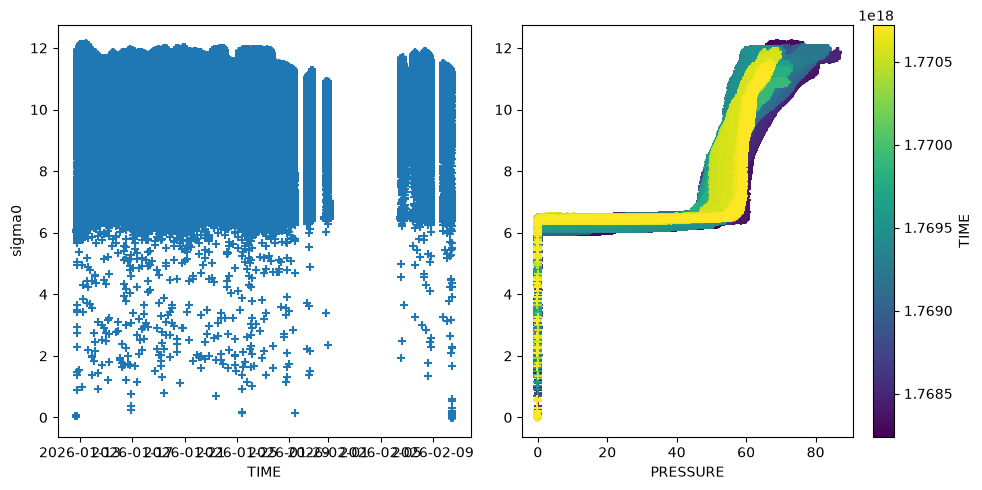

In [10]:
#   Takes a few seconds, but it's worth confirming that our sigma theta values are stable.
#   It should be lowest at the surface, then increase with pressure/depth. At right is a 
#   rotated profile that shows a ton of variability at the surface and a deep layer from 0-40 dbar
#   or so.
fig, axs = plt.subplots(ncols=2, figsize=(10,5))
axs[0].scatter(df["TIME"], df["sigma0"], marker="+")
sc = axs[1].scatter(df["PRES"], df["sigma0"], c=df["TIME"], marker="+")
cbar = plt.colorbar(sc, ax=axs[1])
cbar.set_label("TIME")
axs[0].set_ylabel("sigma0")
axs[0].set_xlabel("TIME")
axs[1].set_xlabel("PRESSURE")
plt.tight_layout()

And now we're looking for our flags.

I *just realized* that if you don't specify either your sus or fail threshold, this test doesn't really do anything.

Since the example in the manual only supports a FAIL flag, let's run with the fail threshold as 0.03 and suspect can be, idunno, let's run with 0.02.

In [11]:
#   And we're looking for our flags.
flags_p = existing_density_inversion_test(df["sigma0"], df["PRES"], suspect_threshold=0.02, fail_threshold=0.03)
flags_d = existing_density_inversion_test(df["sigma0"], df["DEPTH"], suspect_threshold=0.02, fail_threshold=0.03)
print(all(flags_p == flags_d))  #   This confirms that I can trust the derived depth from pressure

True


In [12]:
pl.DataFrame({"flags": flags_p.data}).get_column("flags").value_counts()

flags,count
i64,u32
9,467
1,45712
4,1644132


Ok, so there are a ton of 4 flags and no suspect flags at all. Am I using this right? Let's see what this looks like.

Recall that this is essentially doing $\delta \sigma_{\theta} \over \delta p$, so don't think of it versus time.

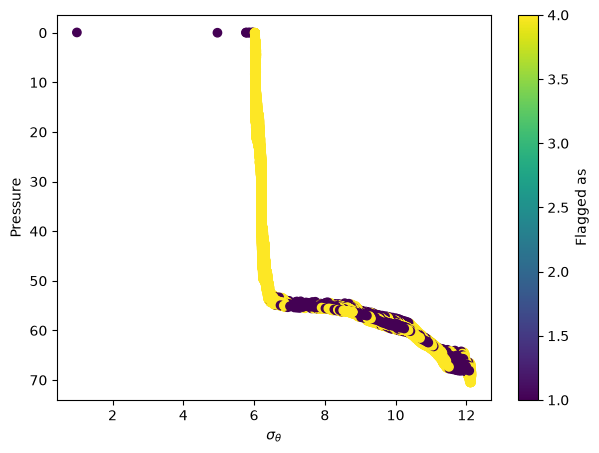

In [13]:
lo = 20000
hi = 40000
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(df["sigma0"][lo:hi], df["PRES"][lo:hi], c=flags_p[lo:hi],)

ax.invert_yaxis()
ax.set_ylabel("Pressure")
ax.set_xlabel(r"$\sigma_\theta$")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Flagged as")

In [16]:
print(df["CNDC"].max() - df["CNDC"].min())
print(df["SP"].max() - df["SP"].min())
print(ds.attrs["basin"])

18.24869973451132
15.834109387119401
Bornholm Basin


We *are* working in an area with some pretty strong stratification. At least, this data is.

What if I'm more lenient.

In [18]:
flags_p = existing_density_inversion_test(df["sigma0"], df["PRES"], suspect_threshold=0.1, fail_threshold=0.5)
flags_d = existing_density_inversion_test(df["sigma0"], df["DEPTH"], suspect_threshold=0.1, fail_threshold=0.5)
print(all(flags_p == flags_d))


True


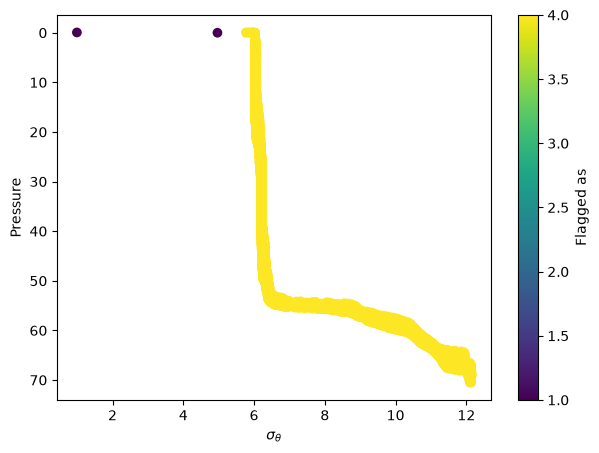

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(df["sigma0"][lo:hi], df["PRES"][lo:hi], c=flags_p[lo:hi],)

ax.invert_yaxis()
ax.set_ylabel("Pressure")
ax.set_xlabel(r"$\sigma_\theta$")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Flagged as")

Wait, I think I'm doing this backwards.

False


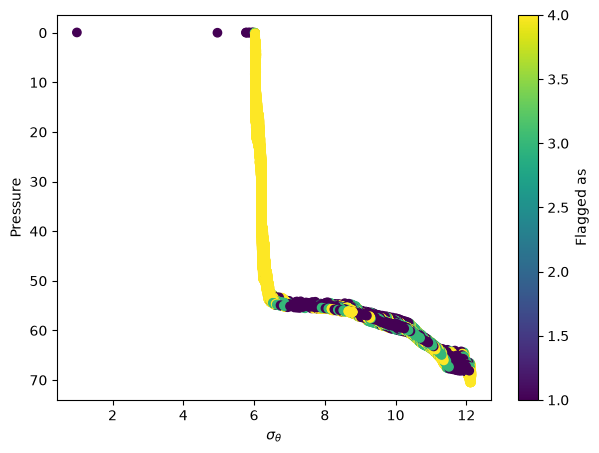

In [20]:
flags_p = existing_density_inversion_test(df["sigma0"], df["PRES"], suspect_threshold=0.03, fail_threshold=0.01)
flags_d = existing_density_inversion_test(df["sigma0"], df["DEPTH"], suspect_threshold=0.03, fail_threshold=0.01)
print(all(flags_p == flags_d))
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(df["sigma0"][lo:hi], df["PRES"][lo:hi], c=flags_p[lo:hi],)
ax.invert_yaxis()
ax.set_ylabel("Pressure")
ax.set_xlabel(r"$\sigma_\theta$")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Flagged as")

Hmmmm... this is why we can't trust `DEPTH` at all times. Somewhere there's a difference between them but that's for another time. I'm going to stick with `PRESS` for now because it's the most "raw" observation.

Okay, so this is giving me *some* sort of result that's flagging correctly. I think some of what makes this problematic is that the `zinp` "verticality" is being calculated on the fly. I have no idea whether it thinks this is doing them together or not. There is no absolute value being applied to the delta so it's possible that everything was getting flagged before because $\delta \sigma_{\theta}$ is being diff'd in its entirety. I don't think this test is actually able to support simultaneous flags?

In [ ]:
delta = pl.DataFrame(np.sign(np.diff(df["PRES"])) * np.diff(df["sigma0"]))
delta.describe()    #   There are negative values in this, which will pretty much always be below the tolerance

In [ ]:
plt.scatter(np.arange(0,len(delta)), delta, c=flags_p[1:])

Are all the negative deltas getting flagged as bad?

In [ ]:
negative = np.asarray(delta).ravel() < 0
flags = np.asarray(flags_p[1:])

print(np.all(flags[negative] == 4))

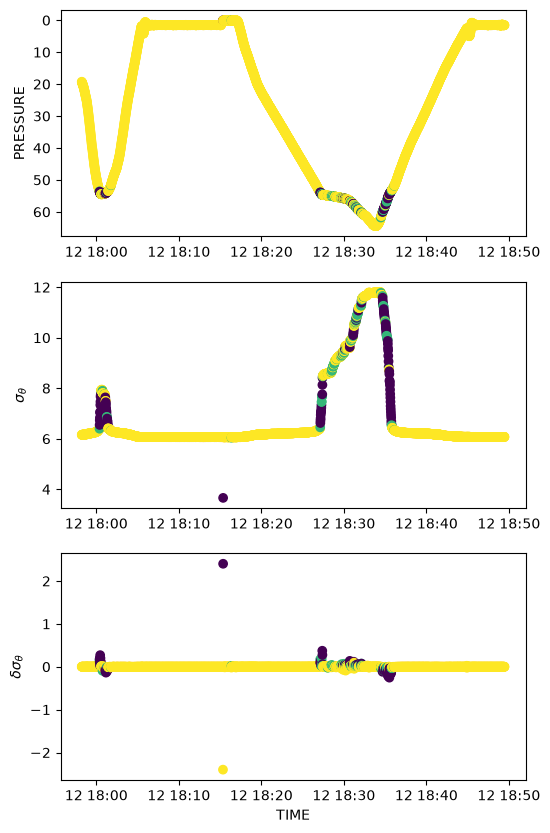

In [26]:
hi, lo = 5000, 2000
dsigma0 = np.diff(df["sigma0"])
fig, axs = plt.subplots(nrows=3, figsize=(6, 10))
sc = axs[0].scatter(df["TIME"][lo:hi], df["PRES"][lo:hi], c=flags_p[lo:hi])
axs[0].invert_yaxis()
axs[0].set_ylabel("PRESSURE")
axs[1].scatter(df["TIME"][lo:hi], df["sigma0"][lo:hi], c=flags_p[lo:hi])
axs[1].set_ylabel(r"$\sigma_\theta$")
axs[2].scatter(df["TIME"][lo:hi], dsigma0[lo:hi], c=flags_p[lo:hi])
axs[2].set_ylabel(r"$\delta \sigma_\theta$")
axs[2].set_xlabel("TIME")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Flagged as")

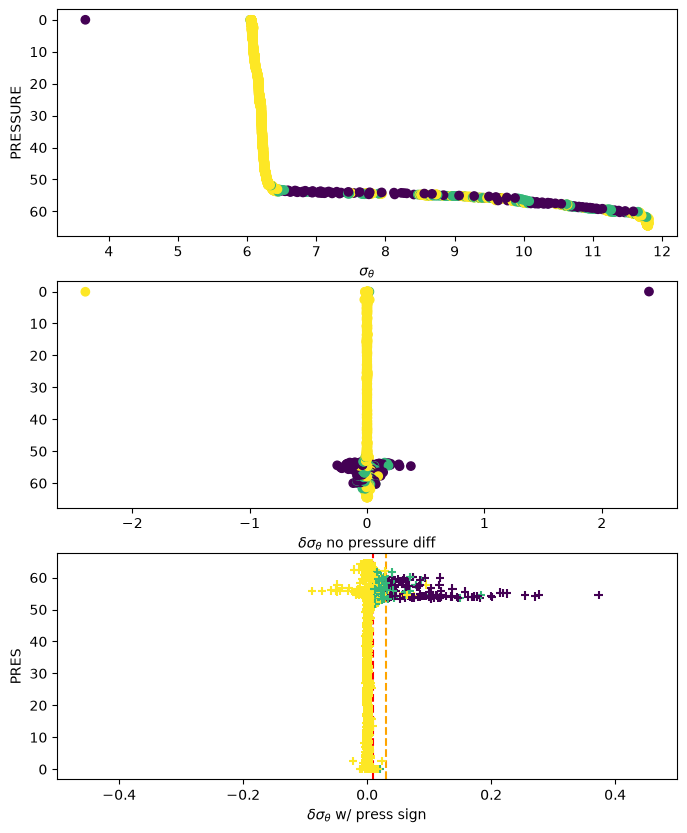

In [56]:
#   Ok, think about it in profile space now
hi, lo = 5000, 2000
dsigma0 = np.diff(df["sigma0"]) #   No sign from pressure taken into account
delta = np.sign(np.diff(df["PRES"])) * np.diff(df["sigma0"])    #   Sign from pressure diff

fig, axs = plt.subplots(nrows=3, figsize=(8, 10))
sc = axs[0].scatter(df["sigma0"][lo:hi], df["PRES"][lo:hi], c=flags_p[lo:hi])
axs[0].invert_yaxis()
axs[0].set_ylabel("PRESSURE")
axs[0].set_xlabel(r"$\sigma_\theta$")
axs[1].scatter(dsigma0[lo:hi], df["PRES"][lo:hi], c=flags_p[lo:hi])
axs[1].set_xlabel(r"$\delta \sigma_\theta$ no pressure diff")
axs[1].invert_yaxis()
axs[2].axvline(x=0.01, linestyle="--", color="red", zorder=0)   #   FAIL
axs[2].axvline(x=0.03, linestyle="--", color="orange", zorder=0)#   SUS
axs[2].scatter(delta[lo:hi], df["PRES"][lo:hi], c=flags_p[lo:hi], marker="+")
axs[2].set_xlabel(r"$\delta \sigma_\theta$ w/ press sign")
axs[2].set_ylabel("PRES")
axs[2].set_xlim([-0.5, 0.5])
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Flagged as")

As per the test description, it should be looking at if the densithy is increasing *sufficiently* with depth. So alllllll of the points where the glider is in the mixed layer are getting flagged but it's all relative to `np.diff(inp)`, not pressure. The function doesn't seem to be accounting for a change in pressure at all with the exception of knowing the sign of the pressure, which isn't absolute.
* Later correction: It makes sense now! It isn't a *single* value to ID the direction of the pressure - it's actually just getting the sign of `dp` at every point and then that gets multiplied through.

I guess it's coming back around to this: Is this test meant to be looking for some fixed amount for the density to be changing by when it moves along, or is it meant to be a true $d\rho \over dt$?
* If it's the former, we should probably implement some kind of absolute function.
    * Later correction: **NO**. This is called the "density inversion test" - you specifically *don't* want to ignore the sign because, well, that's when inversions happen which are bad.
* If it's the latter, we should probably normalize pressure to some sort of small dp such that large changes in pressure will not incorrectly trip tolerances.
    * This *could* be an improvement or a new function but it would be pretty niche for sensors that have lots of gaps, which you might not want to be QCing anyway.

**Reflection**: I confused myself halfway through assessing this test and can confirm that it does in fact work as intended. I thought, for whatever reason, that the direction was being identified using a *single* value for the sign to distinguish between going up and down a la the `pressure test`. That's not the case - $\delta \sigma_{\theta}$ is indeed able to be positive or negative but then that's multiplied by the sign of the pressure. This confused me - because the thresholds are applied to the pressure-sign-adjusted value. I thought it was getting applied earlier and there was a simple "oh if d_sigma is negative it'll always get flagged on the downcast without an absolute value check" brainfart that grabbed me.

The important figure will be the last subplot from above.

This makes it much more obvious where the flagging is being done.

In [ ]:
#   Let's improve the colorbar with discrete flags
import matplotlib.colors as mcolors
cmap = plt.get_cmap("viridis", 4)
norm = mcolors.BoundaryNorm(
    boundaries=[0.5, 1.5, 2.5, 3.5, 4.5],
    ncolors=4,
)

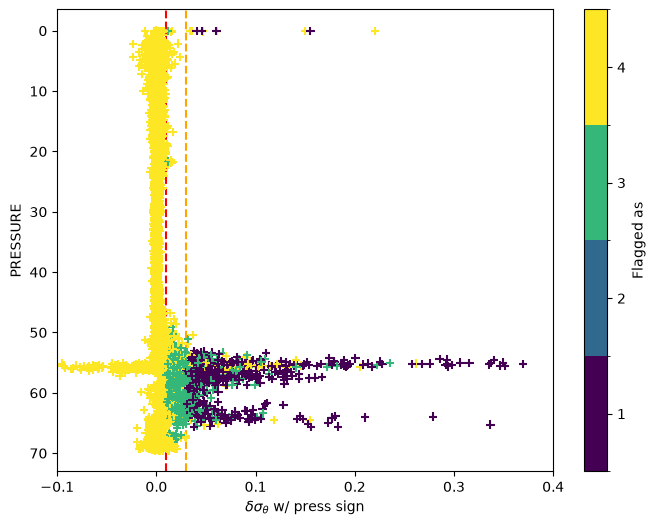

In [68]:
fail_val = 0.01
sus_val = 0.03
flags_p = existing_density_inversion_test(df["sigma0"], df["PRES"],
                                          suspect_threshold=sus_val, fail_threshold=fail_val)
hi, lo = 25000, 12000 #   for plotting a subindex range
dsigma0 = np.diff(df["sigma0"]) #   No sign from pressure taken into account
delta = np.sign(np.diff(df["PRES"])) * np.diff(df["sigma0"])    #   Sign from pressure diff
fig, axs = plt.subplots(figsize=(8, 6))
sc = axs.scatter(delta[lo:hi], df["PRES"][lo:hi], c=flags_p[lo:hi], marker="+",
                 cmap=cmap, norm=norm,)
axs.invert_yaxis()
axs.set_ylabel("PRESSURE")
axs.set_xlabel(r"$\delta \sigma_\theta$ w/ press sign")
axs.axvline(x=fail_val, linestyle="--", color="red", zorder=0)   #   FAIL
axs.axvline(x=sus_val, linestyle="--", color="orange", zorder=0)#   SUS
axs.set_xlim([-0.1, 0.4])
cbar = fig.colorbar(sc, ax=axs, ticks=[1, 2, 3, 4])
cbar.set_label("Flagged as")

But notice above that it doesn't account for everything. Why, then, are there bad values at totally resonable `delta` values? See the "BAD" and "SUSPECT" flags that are popping up at 0.1, 0.2 kg/m3.

I think this comes down to the previous value flagging.

```python
    if suspect_threshold is not None:
        with np.errstate(invalid="ignore"):
            is_suspect = delta < suspect_threshold
            if any(is_suspect):
                flag_arr[:-1][is_suspect == True] = QartodFlags.SUSPECT  # noqa:E712 - Previous value
                flag_arr[1:][is_suspect == True] = QartodFlags.SUSPECT  # noqa:E712 - Reversed value

    if fail_threshold is not None:
        with np.errstate(invalid="ignore"):
            is_fail = delta < fail_threshold
            if any(is_fail):
                flag_arr[:-1][is_fail == True] = QartodFlags.FAIL  # noqa:E712 - Previous value
                flag_arr[1:][is_fail == True] = QartodFlags.FAIL  # noqa:E712 - Reversed Value
```

It's flagging multiple points for each violation. One goes all the way to the end last value, the other goes starting at the first point.

This is probably why it looks a little garbled, because multiple points are getting flagged relative to pressure.

(-0.1, 0.1)

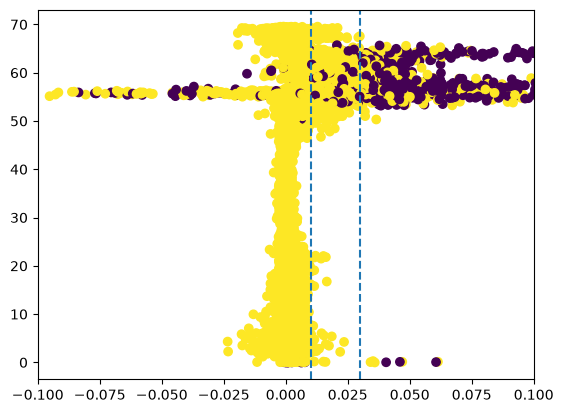

In [ ]:
is_fail = delta < 0.03
#   Shift delta forward by 1.
plt.scatter(delta[lo+1:hi+1], df["PRES"][lo:hi], c=is_fail[lo:hi])
plt.axvline(0.01, linestyle="--")
plt.axvline(0.03, linestyle="--")
plt.xlim([-0.1, 0.1])

Emotional support dataframe

In [ ]:
#   Should eb a bad point between 2 and 3, and 5 and 6. These are INVERSIONS.
df_test = pl.DataFrame({
    "PRES":   [0, 10, 20, 30, 40, 50, 60, 70, 80],
    "sigma0": [14.5, 15.0, 15.2, 15.15, 15.5, 15.7, 15.65, 16.0, 16.1],
})
delta = np.sign(np.diff(df_test["PRES"])) * np.diff(df_test["sigma0"])

Now I can set my tolerances again. Anything, pressure normalized, will fail here if it's not big enough.

In [79]:
fail_val = 0.01
sus_val = 0.03

is_fail = delta < fail_val
is_suspect = delta < sus_val

print("delta:       ", delta)
print("is_suspect:  ", is_suspect)
print("is_fail:     ", is_fail)

delta:        [ 0.5   0.2  -0.05  0.35  0.2  -0.05  0.35  0.1 ]
is_suspect:   [False False  True False False  True False False]
is_fail:      [False False  True False False  True False False]


In [ ]:
flags = existing_density_inversion_test(df_test["sigma0"], df_test["PRES"], suspect_threshold=sus_val, fail_threshold=fail_val)
print(flags)